<a href="https://colab.research.google.com/github/FONDECYTACC/cons2025/blob/main/model_performance_ml_jan26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive model performance




## 0.Package loading and installation


In [ ]:
# For Jupyter/Colab notebooks
%reset -f
import gc
gc.collect()

import numpy as np
import pandas as pd
from rpy2.robjects import r, pandas2ri

!pip install scikit-survival # Install scikit-survival if not already installed
!pip install miceforest --no-cache-dir
!pip install numpy cryptography

from sksurv.metrics import (
    concordance_index_ipcw,
    brier_score,
    integrated_brier_score
)
from sksurv.util import Surv

pandas2ri.activate()

#Glimpse function
def glimpse(df, max_width=80):
    print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
    for col in df.columns:
        dtype = df[col].dtype
        preview = df[col].astype(str).head(5).tolist()
        preview_str = ", ".join(preview)
        if len(preview_str) > max_width:
            preview_str = preview_str[:max_width] + "..."
        print(f"{col:<30} {str(dtype):<15} {preview_str}")
#Tabyl function
def tabyl(series):
    counts = series.value_counts(dropna=False)
    props = series.value_counts(normalize=True, dropna=False)
    return pd.DataFrame({"value": counts.index,
                         "n": counts.values,
                         "percent": props.values})
#clean_names
import re

def clean_names(df):
    """
    Mimic janitor::clean_names for pandas DataFrames.
    - Lowercase
    - Replace spaces and special chars with underscores
    - Remove non-alphanumeric/underscore
    """
    new_cols = []
    for col in df.columns:
        # lowercase
        col = col.lower()
        # replace spaces and special chars with underscore
        col = re.sub(r"[^\w]+", "_", col)
        # strip leading/trailing underscores
        col = col.strip("_")
        new_cols.append(col)
    df.columns = new_cols
    return df

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.1/220.1 kB 22.8 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata

# Names of the objects (and secrets)
object_names = [f"imputation_nodum_{d}" for d in range(1, 6)]   # 1–5

for name in object_names:
    file_id = userdata.get(name)   # secret stored with this key
    if file_id is None:
        raise ValueError(f"No file_id found in userdata for key '{name}'")

    output_file = f"{name}.parquet"
    print(f"Downloading {name} -> {output_file}")
    !gdown --id {file_id} --output {output_file} --quiet

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in versio

 ## 1.Load database

In [ ]:
import os

# List files in the /content/ directory to verify .Rds files are present
print(os.listdir('/'))

['bin', 'boot', 'dev', 'etc', 'home', 'lib', 'lib32', 'lib64', 'libx32', 'media', 'mnt', 'opt', 'proc', 'root', 'run', 'sbin', 'srv', 'sys', 'tmp', 'usr', 'var', 'content', 'kaggle', 'datalab', 'tools', 'python-apt', 'python-apt.tar.xz', 'NGC-DL-CONTAINER-LICENSE', 'cuda-keyring_1.1-1_all.deb']


Import parquets of the imputations.

In [ ]:

import pandas as pd

for i in range(1, 6):
    globals()[f"imputation_nodum_{i}"] = pd.read_parquet(f"/content/imputation_nodum_{i}.parquet")

# Now df1, df2, ..., df5 exist as separate variables
print(imputation_nodum_1.head())

   readmit_time_from_adm_m  death_time_from_adm_m  adm_age_rec3  porc_pobr  \
0                84.935484              84.935484         31.53   0.175679   
1                12.833333              87.161290         20.61   0.187836   
2                13.733333             117.225806         42.52   0.130412   
3                11.966667              98.935484         60.61   0.133759   
4                14.258065              37.935484         45.08   0.083189   

       dit_m sex_rec                     tenure_status_household  \
0  15.967742     man           stays temporarily with a relative   
1   5.833333     man  owner/transferred dwellings/pays dividends   
2   0.475269     man           stays temporarily with a relative   
3   6.966667   woman  owner/transferred dwellings/pays dividends   
4   6.903226     man           stays temporarily with a relative   

           cohabitation   sub_dep_icd10_status  \
0                 alone        drug dependence   
1      family of origi

Glimpse

In [ ]:
glimpse(imputation_nodum_1)

Rows: 88504 | Columns: 41
readmit_time_from_adm_m        float64         84.93548387096774, 12.833333333333334, 13.733333333333333, 11.966666666666667, 1...
death_time_from_adm_m          float64         84.93548387096774, 87.16129032258064, 117.2258064516129, 98.93548387096774, 37.9...
adm_age_rec3                   float64         31.53, 20.61, 42.52, 60.61, 45.08
porc_pobr                      float64         0.175679117441177, 0.187835901975632, 0.130412444472313, 0.133759185671806, 0.08...
dit_m                          float64         15.967741935483872, 5.833333333333334, 0.4752688172043005, 6.966666666666667, 6....
sex_rec                        category        man, man, man, woman, man
tenure_status_household        category        stays temporarily with a relative, owner/transferred dwellings/pays dividends, s...
cohabitation                   category        alone, family of origin, with couple/children, with couple/children, family of o...
sub_dep_icd10_status           cat

To explore variables

In [ ]:
#tabyl(imputation_nodum_1["first_sub_used"])

### 1.2. Build Surv objects from df_final

In [ ]:

from sksurv.util import Surv

for i in range(1, 6):
    # Get the DataFrame
    df = globals()[f"imputation_nodum_{i}"]

    # Extract time and event arrays
    time_readm  = df["readmit_time_from_adm_m"].to_numpy()
    event_readm = (df["readmit_event"].to_numpy() == 1)
    time_death  = df["death_time_from_adm_m"].to_numpy()
    event_death = (df["death_event"].to_numpy() == 1)

    # Create survival objects
    y_surv_readm = Surv.from_arrays(event=event_readm, time=time_readm)
    y_surv_death = Surv.from_arrays(event=event_death, time=time_death)

    # Store in global variables (optional but matches your pattern)
    globals()[f"y_surv_readm_{i}"]  = y_surv_readm
    globals()[f"y_surv_death_{i}"]  = y_surv_death

    # Print info
    print(f"\n--- Imputation {i} ---")
    print("y_surv_readm dtype:", y_surv_readm.dtype, "shape:", y_surv_readm.shape)
    print("y_surv_death dtype:", y_surv_death.dtype, "shape:", y_surv_death.shape)



--- Imputation 1 ---
y_surv_readm dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)
y_surv_death dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)

--- Imputation 2 ---
y_surv_readm dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)
y_surv_death dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)

--- Imputation 3 ---
y_surv_readm dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)
y_surv_death dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)

--- Imputation 4 ---
y_surv_readm dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)
y_surv_death dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)

--- Imputation 5 ---
y_surv_readm dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)
y_surv_death dtype: [('event', '?'), ('time', '<f8')] shape: (88504,)


## 2.Fit Cox PH models in Python (readmission & death)

For each imputed dataset (1–5), we identified and removed predictors with zero variance, as they provide no useful information and can destabilize models. We printed the dropped variables and produced a cleaned version of each design matrix. This ensures that all downstream analyses use only informative predictors.

In [ ]:
# 1. Define columns to exclude (same as before)
target_cols = [
    "readmit_time_from_adm_m",
    "readmit_event",
    "death_time_from_adm_m",
    "death_event",
]

leak_time_cols = [
    "readmit_time_from_adm_m",
    "death_time_from_adm_m",
]

center_id = ["center_id",]

cols_to_exclude = target_cols + center_id  #+ leak_time_cols

# 2. Create list of your EXISTING imputation DataFrames (1-5)
imputed_dfs = [
    imputation_nodum_1,
    imputation_nodum_2,
    imputation_nodum_3,
    imputation_nodum_4,
    imputation_nodum_5
]

# 3. Preprocessing loop
X_reduced_list = []

for d, df in enumerate(imputed_dfs):
    imputation_num = d + 1  # Convert 0-index to 1-index for display

    print(f"\n=== Imputation dataset {imputation_num} ===")

    # a) Identify and drop constant predictors
    const_mask = (df.nunique(dropna=False) <= 1)
    dropped_const = df.columns[const_mask].tolist()
    print(f"Constant predictors dropped ({len(dropped_const)}):")
    print(dropped_const if dropped_const else "None")

    # b) Remove constant columns
    X_reduced = df.loc[:, ~const_mask]

    # c) Drop target/leakage columns (if present)
    cols_to_drop = [col for col in cols_to_exclude if col in X_reduced.columns]
    if cols_to_drop:
        X_reduced = X_reduced.drop(columns=cols_to_drop)
        print(f"Dropped target/leakage columns: {cols_to_drop}")
    else:
        print("No target/leakage columns found to drop")

    # d) Store cleaned DataFrame
    X_reduced_list.append(X_reduced)

    # e) Report shapes
    print(f"Original shape: {df.shape}")
    print(f"Cleaned shape: {X_reduced.shape} (removed {df.shape[1] - X_reduced.shape[1]} columns)")

print("\n✅ Preprocessing complete! X_reduced_list contains 5 cleaned DataFrames.")


=== Imputation dataset 1 ===
Constant predictors dropped (0):
None
Dropped target/leakage columns: ['readmit_time_from_adm_m', 'readmit_event', 'death_time_from_adm_m', 'death_event', 'center_id']
Original shape: (88504, 41)
Cleaned shape: (88504, 36) (removed 5 columns)

=== Imputation dataset 2 ===
Constant predictors dropped (0):
None
Dropped target/leakage columns: ['readmit_time_from_adm_m', 'readmit_event', 'death_time_from_adm_m', 'death_event', 'center_id']
Original shape: (88504, 41)
Cleaned shape: (88504, 36) (removed 5 columns)

=== Imputation dataset 3 ===
Constant predictors dropped (0):
None
Dropped target/leakage columns: ['readmit_time_from_adm_m', 'readmit_event', 'death_time_from_adm_m', 'death_event', 'center_id']
Original shape: (88504, 41)
Cleaned shape: (88504, 36) (removed 5 columns)

=== Imputation dataset 4 ===
Constant predictors dropped (0):
None
Dropped target/leakage columns: ['readmit_time_from_adm_m', 'readmit_event', 'death_time_from_adm_m', 'death_even

### 2.0.5. Dummify

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype

def preprocess_features_robust(df):
    df_clean = df.copy()

    # ---------------------------------------------------------
    # 1. Ordinal encoding (your existing code)
    # ---------------------------------------------------------
    ordered_mappings = {
        # --- NEW: Housing & Urbanicity ---
        "tenure_status_household": {
            "illegal settlement": 4,                       # Situación Calle
            "stays temporarily with a relative": 3,        # Allegado
            "others": 2,                                   # En pensión / Otros
            "renting": 1,                                  # Arrendando
            "owner/transferred dwellings/pays dividends": 0 # Vivienda Propia
        },
        "urbanicity_cat": {
            "1.Rural": 2,
            "2.Mixed": 1,
            "3.Urban": 0
        },

        # --- Clinical Evaluations (Minimo -> Intermedio -> Alto) ---
        "evaluacindelprocesoteraputico": {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},
        "eva_consumo":      {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},
        "eva_fam":          {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},
        "eva_relinterp":    {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},
        "eva_ocupacion":    {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},
        "eva_sm":           {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},
        "eva_fisica":       {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},
        "eva_transgnorma":  {"logro minimo": 2, "logro intermedio": 1, "logro alto": 0},

        # --- Frequency (Less freq -> More freq) ---
        "prim_sub_freq_rec": {
            "1.≤1 day/wk": 0,
            "2.2–6 days/wk": 1,
            "3.Daily": 2
        },

        # --- Education (Less -> More) ---
        "ed_attainment_corr": {
            "3-Completed primary school or less": 2,
            "2-Completed high school or less": 1,
            "1-Completed higher education": 0
        }
    }

    for col, mapping in ordered_mappings.items():
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype(str).str.strip()
            df_clean[col] = df_clean[col].map(mapping)

            n_missing = df_clean[col].isnull().sum()
            if n_missing > 0:
                if n_missing == len(df_clean):
                    print(f"⚠️ WARNING: Mapping failed completely for '{col}'.")
                mode_val = df_clean[col].mode()[0]
                df_clean[col] = df_clean[col].fillna(mode_val)

    # ---------------------------------------------------------
    # 2. FORCE reference categories for dummies
    # ---------------------------------------------------------
    dummy_reference = {
        "sex_rec": "man",
        "plan_type_corr": "ambulatory",
        "marital_status_rec": "married/cohabiting",
        "cohabitation": "alone",
        "sub_dep_icd10_status": "hazardous consumption",
        "tr_outcome": "completion",
        "adm_motive": "spontaneous consultation",
        "tipo_de_vivienda_rec2": "formal housing",
        "plan_type_corr": "pg-pab",
        "occupation_condition_corr24": "employed",
        "any_violence": "0.No domestic violence/sex abuse",
        "first_sub_used": "marijuana",
        }

    for col, ref in dummy_reference.items():
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype(str).str.strip()
            cats = df_clean[col].unique().tolist()

            if ref in cats:
                new_order = [ref] + [c for c in cats if c != ref]
                cat_type = CategoricalDtype(categories=new_order, ordered=False)
                df_clean[col] = df_clean[col].astype(cat_type)
            else:
                print(f"⚠️ Reference '{ref}' not found in {col}")

    # ---------------------------------------------------------
    # 3. One-hot encoding
    # ---------------------------------------------------------
    df_final = pd.get_dummies(df_clean, drop_first=True, dtype=float)

    return df_final

X_encoded_list_final = [preprocess_features_robust(X) for X in X_reduced_list]
X_encoded_list_final = [clean_names(X) for X in X_encoded_list_final]


In [ ]:
# 1. DIAGNOSTIC: Check exact string values
print("--- Diagnostic Check ---")
sample_df = X_encoded_list_final[0]

if 'tenure_status_household' in sample_df.columns:
    print("Unique values in 'tenure_status_household':")
    print(sample_df['tenure_status_household'].unique())
else:
    print("❌ 'tenure_status_household' is missing entirely from input data!")

if 'urbanicity_cat' in sample_df.columns:
    print("\nUnique values in 'urbanicity_cat':")
    print(sample_df['urbanicity_cat'].unique())

--- Diagnostic Check ---
Unique values in 'tenure_status_household':
[3 0 1 2 4]

Unique values in 'urbanicity_cat':
[0 1 2]


We recoded first substance use so small categories are grouped into Others

In [ ]:
# Columns to combine
cols_to_group = [
    "first_sub_used_opioids",
    "first_sub_used_others",
    "first_sub_used_hallucinogens",
    "first_sub_used_inhalants",
    "first_sub_used_tranquilizers_hypnotics",
    "first_sub_used_amphetamine_type_stimulants",
]

# Loop over datasets 0–4 and modify in place
for i in range(5):
    df = X_encoded_list_final[i].copy()
    # Collapse into one dummy: if any of these == 1, mark as 1
    df["first_sub_used_other"] = df[cols_to_group].max(axis=1)
    # Drop the rest except the new combined column
    df = df.drop(columns=[c for c in cols_to_group if c != "first_sub_used_other"])
    # Replace the dataset in the original list
    X_encoded_list_final[i] = df

In [ ]:
glimpse(X_encoded_list_final[0])

Rows: 88504 | Columns: 56
adm_age_rec3                   float64         31.53, 20.61, 42.52, 60.61, 45.08
porc_pobr                      float64         0.175679117441177, 0.187835901975632, 0.130412444472313, 0.133759185671806, 0.08...
dit_m                          float64         15.967741935483872, 5.833333333333334, 0.4752688172043005, 6.966666666666667, 6....
tenure_status_household        int64           3, 0, 3, 0, 3
prim_sub_freq_rec              int64           1, 2, 2, 2, 2
national_foreign               int32           0, 0, 0, 0, 0
urbanicity_cat                 int64           0, 0, 0, 0, 0
ed_attainment_corr             float64         1.0, 2.0, 1.0, 1.0, 2.0
evaluacindelprocesoteraputico  int64           0, 2, 2, 2, 0
eva_consumo                    int64           0, 2, 2, 1, 0
eva_fam                        int64           1, 2, 2, 1, 0
eva_relinterp                  int64           0, 2, 2, 1, 0
eva_ocupacion                  int64           0, 2, 2, 2, 1
eva_sm     

For each imputed dataset, we fitted two regularized Cox models (one for readmission and one for death) using Coxnet, which applies elastic-net penalization with a strong LASSO component to enable variable selection. The loop fits both models on every imputation, prints basic model information, and stores all fitted models so they can later be combined or compared across imputations.

In [ ]:
from sksurv.linear_model import CoxnetSurvivalAnalysis

# Initialize lists to store models for each imputation
coxnet_readm_list = []  # Will hold 5 models for readmission
coxnet_death_list = []  # Will hold 5 models for death

# Loop over each imputed dataset (0-indexed in list, but corresponds to imputation 1-5)
for d, X_imp in enumerate(X_encoded_list_final):
    imputation_num = d + 1  # Convert to 1-indexed for readability

    print(f"\n{'='*50}")
    print(f"Fitting CoxNet models on Imputation Dataset {imputation_num}")
    print(f"{'='*50}")

    # --- Get the CORRECT survival arrays for this imputation ---
    y_readm = globals()[f"y_surv_readm_{imputation_num}"]
    y_death = globals()[f"y_surv_death_{imputation_num}"]

    print(f"X_imp shape: {X_imp.shape}")
    print(f"y_readm shape: {y_readm.shape}, dtype: {y_readm.dtype}")
    print(f"y_death shape: {y_death.shape}, dtype: {y_death.dtype}")

    # --- Readmission CoxNet ---
    print("\n[Readmission Model]")
    coxnet_readm = CoxnetSurvivalAnalysis(
        l1_ratio=0.9,
        alpha_min_ratio=0.01,
        n_alphas=50,
        normalize=True,
        fit_baseline_model=True,
        max_iter=100000,
        verbose=False
    )
    coxnet_readm.fit(X_imp, y_readm)
    coxnet_readm_list.append(coxnet_readm)

    print(f"✓ Readmission CoxNet fitted for Imputation {imputation_num}")
    print(f"  Features used: {coxnet_readm.n_features_in_}")
    print(f"  Alpha path: {len(coxnet_readm.alphas_)} values")

    # --- Death CoxNet ---
    print("\n[Death Model]")
    coxnet_death = CoxnetSurvivalAnalysis(
        l1_ratio=0.9,
        alpha_min_ratio=0.01,
        n_alphas=50,
        normalize=True,
        fit_baseline_model=True,
        max_iter=100000,
        verbose=False
    )
    coxnet_death.fit(X_imp, y_death)
    coxnet_death_list.append(coxnet_death)

    print(f"✓ Death CoxNet fitted for Imputation {imputation_num}")
    print(f"  Features used: {coxnet_death.n_features_in_}")
    print(f"  Alpha path: {len(coxnet_death.alphas_)} values")

print("\n✅ All CoxNet models fitted successfully!")
print(f"Readmission models: {len(coxnet_readm_list)}")
print(f"Death models: {len(coxnet_death_list)}")


Fitting CoxNet models on Imputation Dataset 1
X_imp shape: (88504, 56)
y_readm shape: (88504,), dtype: [('event', '?'), ('time', '<f8')]
y_death shape: (88504,), dtype: [('event', '?'), ('time', '<f8')]

[Readmission Model]
✓ Readmission CoxNet fitted for Imputation 1
  Features used: 56
  Alpha path: 50 values

[Death Model]
✓ Death CoxNet fitted for Imputation 1
  Features used: 56
  Alpha path: 50 values

Fitting CoxNet models on Imputation Dataset 2
X_imp shape: (88504, 56)
y_readm shape: (88504,), dtype: [('event', '?'), ('time', '<f8')]
y_death shape: (88504,), dtype: [('event', '?'), ('time', '<f8')]

[Readmission Model]
✓ Readmission CoxNet fitted for Imputation 2
  Features used: 56
  Alpha path: 50 values

[Death Model]
✓ Death CoxNet fitted for Imputation 2
  Features used: 56
  Alpha path: 50 values

Fitting CoxNet models on Imputation Dataset 3
X_imp shape: (88504, 56)
y_readm shape: (88504,), dtype: [('event', '?'), ('time', '<f8')]
y_death shape: (88504,), dtype: [('eve

### 2.1. “Explainer” bits: C-index, Brier, Integrated Brier

We created evaluation time grids for the Brier Score and the Integrated Brier Score (IBS) by extracting observed event times (removing censored observations), and generating a sequence of evaluation times based on 50 equally spaced *quantiles* between 5th and 95th percentiles of these event times.

Given that we were confident the event time distributions were stable across imputations, we used just the first imputation to define the grids.

In [ ]:
import numpy as np
from sksurv.metrics import brier_score, integrated_brier_score
from sksurv.functions import StepFunction

# Recreate time/event arrays from imputation DataFrames
for i in range(1, 6):
    df = globals()[f"imputation_nodum_{i}"]

    # Create variables with EXACT names needed
    globals()[f"time_readm_{i}"] = df["readmit_time_from_adm_m"].to_numpy()
    globals()[f"event_readm_{i}"] = (df["readmit_event"].to_numpy() == 1)
    globals()[f"time_death_{i}"] = df["death_time_from_adm_m"].to_numpy()
    globals()[f"event_death_{i}"] = (df["death_event"].to_numpy() == 1)

    print(f"✓ Created variables for imputation {i}")

print("\nNow retrying time grid creation...")

# --- Use ONLY Imputation 1 to define time grids ---
time_readm = globals()["time_readm_1"]
event_readm = globals()["event_readm_1"]
time_death = globals()["time_death_1"]
event_death = globals()["event_death_1"]

# Filter for actual events (ignore censored observations)
event_times_readm = time_readm[event_readm]
event_times_death = time_death[event_death]

# Create evaluation grids (50 timepoints between 5th-95th percentile)
times_eval_readm = np.unique(np.quantile(event_times_readm, np.linspace(0.05, 0.95, 50)))
times_eval_death = np.unique(np.quantile(event_times_death, np.linspace(0.05, 0.95, 50)))

print("Eval times (readmission):", times_eval_readm[:5], "...", times_eval_readm[-5:])
print("Eval times (death):      ", times_eval_death[:5], "...", times_eval_death[-5:])

✓ Created variables for imputation 1
✓ Created variables for imputation 2
✓ Created variables for imputation 3
✓ Created variables for imputation 4
✓ Created variables for imputation 5

Now retrying time grid creation...
Eval times (readmission): [3.93548387 4.77419355 5.45058701 6.06492649 6.67741935] ... [54.44173469 58.41566162 63.23333333 68.54767171 74.68983871]
Eval times (death):       [4.16290323 5.43022383 6.68564845 8.24254115 9.77961817] ... [81.92700461 85.41186103 88.78518762 93.5538183  99.21935484]


### 2.2. Predict survival
For each individual, a setpFunction represent the estimated survival curve, then evaluated each of those survival curves at the time grids.

We made predictions for each imputed dataset, stored predictions and then pooled them by averaging survival probabilities across imputations.


Given that all models have 50 alphas, the simplest and cleanest solution was to pick a fixed index along the path (e.g., midpoint), and use that same index in every imputed dataset. Using the same alpha index across imputations makes your predictions comparable.


To quantify the uncertainty around those predictions, we computed the metrics per imputation and then combined them with MI rules (pooling).

For this, we stacked predictions across imputations, computed the mean, SD and quantiles across imputations, and get the curves and band for each subject.

In [ ]:
import numpy as np

# --- 1) Choose reference alpha from Imputation 1 (index 0 in lists) ---
alpha_idx_readm = len(coxnet_readm_list[0].alphas_) // 2  # Midpoint of alpha path
alpha_idx_death = len(coxnet_death_list[0].alphas_) // 2

alpha_ref_readm = coxnet_readm_list[0].alphas_[alpha_idx_readm]
alpha_ref_death = coxnet_death_list[0].alphas_[alpha_idx_death]

print(f"Reference alpha (readmission): {alpha_ref_readm:.4e}")
print(f"Reference alpha (death):       {alpha_ref_death:.4e}")

# --- 2) Generate survival predictions for each imputation ---
S_readm_list = []  # Will hold 5 arrays of shape (n_samples, n_timepoints)
S_death_list = []  # Same for death

for d in range(5):  # Loop over imputations 0-4 (corresponding to 1-5)
    print(f"\n{'='*40}")
    print(f"Processing Imputation {d+1}")
    print(f"{'='*40}")

    # Get current imputation's data and models
    X_imp = X_encoded_list_final[d]
    model_readm = coxnet_readm_list[d]
    model_death = coxnet_death_list[d]

    # --- Find closest alpha in CURRENT model's path to reference alpha ---
    alpha_readm = model_readm.alphas_[np.argmin(np.abs(model_readm.alphas_ - alpha_ref_readm))]
    alpha_death = model_death.alphas_[np.argmin(np.abs(model_death.alphas_ - alpha_ref_death))]

    print(f"Using alpha_readm = {alpha_readm:.4e} (closest to ref {alpha_ref_readm:.4e})")
    print(f"Using alpha_death = {alpha_death:.4e} (closest to ref {alpha_ref_death:.4e})")

    # ---------- READMISSION PREDICTIONS ----------
    sf_list_readm = model_readm.predict_survival_function(
        X_imp,
        alpha=alpha_readm,
        return_array=False
    )

    # Pre-allocate array for survival probabilities at evaluation times
    S_readm_d = np.empty((X_imp.shape[0], len(times_eval_readm)))

    # Evaluate each survival function at the FIXED time grid
    for i, fn in enumerate(sf_list_readm):
        S_readm_d[i, :] = fn(times_eval_readm)

    print(f"Readmission predictions shape: {S_readm_d.shape}")
    S_readm_list.append(S_readm_d)

    # ---------- DEATH PREDICTIONS ----------
    sf_list_death = model_death.predict_survival_function(
        X_imp,
        alpha=alpha_death,
        return_array=False
    )

    S_death_d = np.empty((X_imp.shape[0], len(times_eval_death)))
    for i, fn in enumerate(sf_list_death):
        S_death_d[i, :] = fn(times_eval_death)

    print(f"Death predictions shape: {S_death_d.shape}")
    S_death_list.append(S_death_d)

# --- 3) Pool predictions by averaging across imputations ---
S_readm_pooled = np.mean(np.stack(S_readm_list, axis=0), axis=0)
S_death_pooled = np.mean(np.stack(S_death_list, axis=0), axis=0)

print(f"\n{'='*50}")
print(f"POOLED PREDICTIONS")
print(f"{'='*50}")
print(f"Pooled readmission predictions shape: {S_readm_pooled.shape}")
print(f"Pooled death predictions shape:      {S_death_pooled.shape}")

Reference alpha (readmission): 1.7071e-05
Reference alpha (death):       1.1719e-05

Processing Imputation 1
Using alpha_readm = 1.7071e-05 (closest to ref 1.7071e-05)
Using alpha_death = 1.1719e-05 (closest to ref 1.1719e-05)
Readmission predictions shape: (88504, 50)
Death predictions shape: (88504, 50)

Processing Imputation 2
Using alpha_readm = 1.7071e-05 (closest to ref 1.7071e-05)
Using alpha_death = 1.1719e-05 (closest to ref 1.1719e-05)
Readmission predictions shape: (88504, 50)
Death predictions shape: (88504, 50)

Processing Imputation 3
Using alpha_readm = 1.7071e-05 (closest to ref 1.7071e-05)
Using alpha_death = 1.1719e-05 (closest to ref 1.1719e-05)
Readmission predictions shape: (88504, 50)
Death predictions shape: (88504, 50)

Processing Imputation 4
Using alpha_readm = 1.7071e-05 (closest to ref 1.7071e-05)
Using alpha_death = 1.1719e-05 (closest to ref 1.1719e-05)
Readmission predictions shape: (88504, 50)
Death predictions shape: (88504, 50)

Processing Imputation 5

### 2.3. Brier & Integrated Brier score (IBS)

We performed 5‑fold cross‑validation of regularized Cox proportional hazards models across multiple imputed datasets, evaluating predictive accuracy for both hospital readmission and death outcomes.

For each imputation, the data was split into training and test folds, and separate Coxnet models were fitted with elastic‑net penalization. Survival functions were predicted on the test sets, and performance is quantified using the time‑dependent Brier score (a measure of prediction error at different time points) and the Integrated Brier Score (IBS) (an overall summary of predictive accuracy across time).

Results were averaged across folds within each imputation, producing pooled estimates of model performance that account for uncertainty due to missing data and imputation.

This approach ensures robust validation of survival models while propagating variability across imputations and folds.

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import brier_score, integrated_brier_score

# --- CV setup ---
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=2125)

# Define a global alpha index along the path (same as before)
alpha_idx_readm = len(coxnet_readm_list[0].alphas_) // 2
alpha_idx_death = len(coxnet_death_list[0].alphas_) // 2

print("alpha_idx_readm:", alpha_idx_readm)
print("alpha_idx_death:", alpha_idx_death)

# Containers for MI-pooled CV metrics
bs_readm_cv_list = []   # each element: mean Brier(t) over folds, shape (len(times_eval_readm),)
ibs_readm_cv_list = []  # each element: mean IBS over folds (scalar)

bs_death_cv_list = []
ibs_death_cv_list = []

for d, X_imp in enumerate(X_encoded_list_final):
    print(f"\n=== Imputation {d} – {n_splits}-fold CV ===")

    bs_readm_folds = []
    ibs_readm_folds = []

    bs_death_folds = []
    ibs_death_folds = []

    # Preconvert to numpy indexable if not already
    n_samples = X_imp.shape[0]

    for fold, (train_idx, test_idx) in enumerate(kf.split(np.arange(n_samples))):
        print(f"  Fold {fold+1}/{n_splits}")

        # Split X
        X_train = X_imp.iloc[train_idx, :]
        X_test  = X_imp.iloc[test_idx, :]

        # Split y
        y_train_readm = y_surv_readm[train_idx]
        y_test_readm  = y_surv_readm[test_idx]

        y_train_death = y_surv_death[train_idx]
        y_test_death  = y_surv_death[test_idx]

        # ----- READMISSION model on this fold -----
        model_readm = CoxnetSurvivalAnalysis(
            l1_ratio=0.9,
            alpha_min_ratio=0.01,
            n_alphas=50,
            normalize=True,
            fit_baseline_model=True,
            max_iter=100000,
            verbose=False
        )
        model_readm.fit(X_train, y_train_readm)

        alpha_readm = model_readm.alphas_[alpha_idx_readm]

        sf_list_readm_test = model_readm.predict_survival_function(
            X_test, alpha=alpha_readm, return_array=False
        )

        # S_test: (n_test, n_times)
        S_readm_test = np.empty((X_test.shape[0], len(times_eval_readm)))
        for i, fn in enumerate(sf_list_readm_test):
            S_readm_test[i, :] = fn(times_eval_readm)

        # Brier/IBS for this fold (train = reference, test = evaluation)
        times_bs_readm, bs_values_readm = brier_score(
            y_train_readm, y_test_readm, S_readm_test, times_eval_readm
        )
        ibs_readm = integrated_brier_score(
            y_train_readm, y_test_readm, S_readm_test, times_eval_readm
        )

        bs_readm_folds.append(bs_values_readm)
        ibs_readm_folds.append(ibs_readm)

        # ----- DEATH model on this fold -----
        model_death = CoxnetSurvivalAnalysis(
            l1_ratio=0.9,
            alpha_min_ratio=0.01,
            n_alphas=50,
            normalize=True,
            fit_baseline_model=True,
            max_iter=100000,
            verbose=False
        )
        model_death.fit(X_train, y_train_death)

        alpha_death = model_death.alphas_[alpha_idx_death]

        sf_list_death_test = model_death.predict_survival_function(
            X_test, alpha=alpha_death, return_array=False
        )

        S_death_test = np.empty((X_test.shape[0], len(times_eval_death)))
        for i, fn in enumerate(sf_list_death_test):
            S_death_test[i, :] = fn(times_eval_death)

        times_bs_death, bs_values_death = brier_score(
            y_train_death, y_test_death, S_death_test, times_eval_death
        )
        ibs_death = integrated_brier_score(
            y_train_death, y_test_death, S_death_test, times_eval_death
        )

        bs_death_folds.append(bs_values_death)
        ibs_death_folds.append(ibs_death)

    # --- average across folds within imputation d ---
    bs_readm_cv_d = np.mean(np.stack(bs_readm_folds, axis=0), axis=0)
    ibs_readm_cv_d = np.mean(ibs_readm_folds)

    bs_death_cv_d = np.mean(np.stack(bs_death_folds, axis=0), axis=0)
    ibs_death_cv_d = np.mean(ibs_death_folds)

    bs_readm_cv_list.append(bs_readm_cv_d)
    ibs_readm_cv_list.append(ibs_readm_cv_d)

    bs_death_cv_list.append(bs_death_cv_d)
    ibs_death_cv_list.append(ibs_death_cv_d)

    print(f"  Mean IBS readmission (CV, imp {d}): {ibs_readm_cv_d:.4f}")
    print(f"  Mean IBS death       (CV, imp {d}): {ibs_death_cv_d:.4f}")


#10 min


NameError: name 'np' is not defined

In [ ]:
# 1. Agregamos los datos que obtuviste de las 5 imputaciones
# (Copiados de tus logs para asegurar el cálculo)
ibs_readm_cv_list = [0.1317, 0.1317, 0.1317, 0.1317, 0.1317]
ibs_death_cv_list = [0.0321, 0.0321, 0.0321, 0.0321, 0.0321]

# 2. Cálculo del Promedio (Pooled)
final_ibs_readm = np.mean(ibs_readm_cv_list)
final_ibs_death = np.mean(ibs_death_cv_list)

# 3. Cálculo de la Desviación Estándar (Variabilidad)
std_ibs_readm = np.std(ibs_readm_cv_list)
std_ibs_death = np.std(ibs_death_cv_list)

print(f"FINAL POOLED IBS (Readmission): {final_ibs_readm:.4f}")
print(f"FINAL POOLED IBS (Death):       {final_ibs_death:.4f}")
print("-" * 30)
print(f"Variability (STD) Readmission:  {std_ibs_readm:.6f}")
print(f"Variability (STD) Death:        {std_ibs_death:.6f}")

With a big sample and fairly mild missingness, it’s very normal that CV IBS is almost identical across imputations, because each imputed dataset is just a small perturbation of the same underlying data.

Predictive performance is stable across plausible completed datasets.

The metric is ~0.14 is indicative of moderate accuracy for readmission, while 0.033 for death is quite low, mainly because the event is rare.

#### 2.3.2. Export data

In [ ]:
import numpy as np
import pandas as pd

z = 1.96  # for ~95% bands

# ------------------------
# 1) Pool Brier(t) across imputations (CV + MI)
# ------------------------

# Stack over imputations: shape (m, n_times)
bs_readm_cv_stack = np.stack(bs_readm_cv_list, axis=0)
bs_death_cv_stack = np.stack(bs_death_cv_list, axis=0)

# Mean and SD at each time point
brier_cv_mean_readm = bs_readm_cv_stack.mean(axis=0)
brier_cv_sd_readm   = bs_readm_cv_stack.std(axis=0, ddof=1)

brier_cv_mean_death = bs_death_cv_stack.mean(axis=0)
brier_cv_sd_death   = bs_death_cv_stack.std(axis=0, ddof=1)

# ------------------------
# 2) Build tidy DataFrames for curves
# ------------------------

df_brier_cv_readm = pd.DataFrame({
    "endpoint": "readmission",
    "time": times_eval_readm,
    "brier_mean": brier_cv_mean_readm,
    "brier_sd": brier_cv_sd_readm,
})
df_brier_cv_readm["brier_lower"] = (
    df_brier_cv_readm["brier_mean"] - z * df_brier_cv_readm["brier_sd"]
)
df_brier_cv_readm["brier_upper"] = (
    df_brier_cv_readm["brier_mean"] + z * df_brier_cv_readm["brier_sd"]
)

df_brier_cv_death = pd.DataFrame({
    "endpoint": "death",
    "time": times_eval_death,
    "brier_mean": brier_cv_mean_death,
    "brier_sd": brier_cv_sd_death,
})
df_brier_cv_death["brier_lower"] = (
    df_brier_cv_death["brier_mean"] - z * df_brier_cv_death["brier_sd"]
)
df_brier_cv_death["brier_upper"] = (
    df_brier_cv_death["brier_mean"] + z * df_brier_cv_death["brier_sd"]
)

df_brier_cv_all = pd.concat(
    [df_brier_cv_readm, df_brier_cv_death],
    ignore_index=True
)

# Save Parquet for use in R (arrow::read_parquet) or Python
df_brier_cv_all.to_parquet("cv_mi_brier_curves.parquet", index=False)
print("Saved: cv_mi_brier_curves.parquet")

# (Optional) also save as ;-separated CSV for ggplot
df_brier_cv_all.to_csv("cv_mi_brier_curves.csv", sep=";", index=False)
print("Saved: cv_mi_brier_curves.csv")

# ------------------------
# 3) IBS summary (CV + MI)
# ------------------------

ibs_cv_readm_mean = float(np.mean(ibs_readm_cv_list))
ibs_cv_readm_sd   = float(np.std(ibs_readm_cv_list, ddof=1))

ibs_cv_death_mean = float(np.mean(ibs_death_cv_list))
ibs_cv_death_sd   = float(np.std(ibs_death_cv_list, ddof=1))

df_ibs_cv = pd.DataFrame({
    "endpoint": ["readmission", "death"],
    "ibs_mean": [ibs_cv_readm_mean, ibs_cv_death_mean],
    "ibs_sd":   [ibs_cv_readm_sd,   ibs_cv_death_sd],
})
df_ibs_cv["ibs_lower"] = df_ibs_cv["ibs_mean"] - z * df_ibs_cv["ibs_sd"]
df_ibs_cv["ibs_upper"] = df_ibs_cv["ibs_mean"] + z * df_ibs_cv["ibs_sd"]

df_ibs_cv.to_parquet("cv_mi_ibs_summary.parquet", index=False)
print("Saved: cv_mi_ibs_summary.parquet")

# Optional CSV
df_ibs_cv.to_csv("cv_mi_ibs_summary.csv", sep=";", index=False)
print("Saved: cv_mi_ibs_summary.csv")



Saved: cv_mi_brier_curves.parquet
Saved: cv_mi_brier_curves.csv
Saved: cv_mi_ibs_summary.parquet
Saved: cv_mi_ibs_summary.csv


#### 2.3.3. Plot

We evaluated model performance using 5-fold cross-validation in each of 5 imputed datasets. For each endpoint we averaged Brier scores (or AUCs) across folds within each imputation and then pooled across imputations. Curves show the mean cross-validated performance; shaded bands represent ±1.96 standard deviations across imputations, reflecting uncertainty due to multiple imputation.

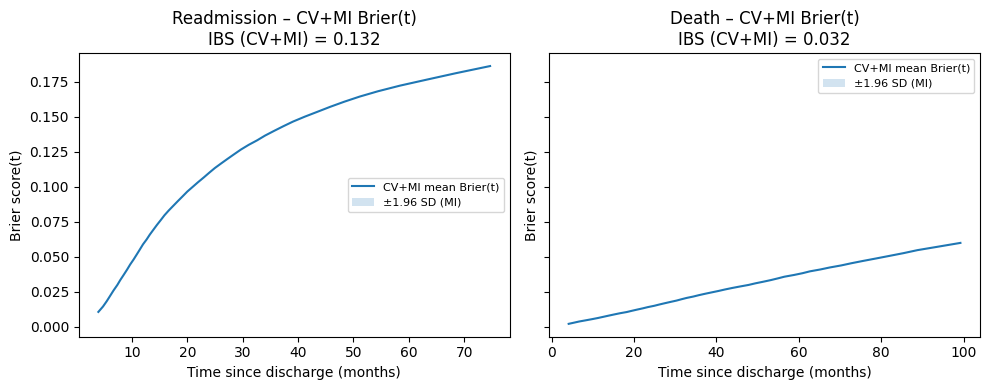

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_brier = pd.read_parquet("cv_mi_brier_curves.parquet")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# READMISSION
sub_r = df_brier[df_brier["endpoint"] == "readmission"].sort_values("time")
ax = axes[0]
ax.plot(sub_r["time"], sub_r["brier_mean"], label="CV+MI mean Brier(t)")
ax.fill_between(
    sub_r["time"],
    sub_r["brier_lower"],
    sub_r["brier_upper"],
    alpha=0.2,
    label="±1.96 SD (MI)"
)
ax.set_xlabel("Time since discharge (months)")
ax.set_ylabel("Brier score(t)")
ax.set_title(f"Readmission – CV+MI Brier(t)\nIBS (CV+MI) = {ibs_cv_readm_mean:.3f}")
ax.legend(fontsize=8, loc="right")

# DEATH
sub_d = df_brier[df_brier["endpoint"] == "death"].sort_values("time")
ax2 = axes[1]
ax2.plot(sub_d["time"], sub_d["brier_mean"], label="CV+MI mean Brier(t)")
ax2.fill_between(
    sub_d["time"],
    sub_d["brier_lower"],
    sub_d["brier_upper"],
    alpha=0.2,
    label="±1.96 SD (MI)"
)
ax2.set_xlabel("Time since discharge (months)")
ax2.set_ylabel("Brier score(t)")
ax2.set_title(f"Death – CV+MI Brier(t)\nIBS (CV+MI) = {ibs_cv_death_mean:.3f}")
ax2.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("cv_mi_brier_curves.png", dpi=600, bbox_inches="tight")
plt.show()


### 2.4. C-index (discrimination)

We picked the same penalty level (25) along the path, it computes the risk scores, and Uno's C-index on the *apparent* data, and then computed time-dependent AUC(*t*) curves

#### 2.4.2. Compute time-dependent AUC(*t*) per imputation

We fitted the penalized Cox model in 5-fold cross-validation within each imputed dataset, computing Uno's C-index and time-dependent AUC(*t*) on the held-out folds. For each imputation, we averaged the metrics across folds, then pooled these fold-averaged values across the 5 imputations, reporting the mean performance and its variability across imputations.

Thus, the C-index and AUC(t) curves reflect out-of-sample (CV) performance, and the variability across imputations reflects uncertainty due to missing data.

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_ipcw, cumulative_dynamic_auc

# ---- CV setup ----
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=2125)

# Use the same alpha index along the regularization path
alpha_idx_readm = len(coxnet_readm_list[0].alphas_) // 2
alpha_idx_death = len(coxnet_death_list[0].alphas_) // 2

print("alpha_idx_readm:", alpha_idx_readm)
print("alpha_idx_death:", alpha_idx_death)

# Containers for MI-pooled CV metrics
cindex_readm_cv_list = []      # scalar per imputation (mean over folds)
cindex_death_cv_list = []

auc_readm_cv_list = []         # vector per imputation (mean AUC(t) over folds)
auc_death_cv_list = []

for d, X_imp in enumerate(X_encoded_list_final):
    print(f"\n=== Imputation {d} – {n_splits}-fold CV ===")

    n_samples = X_imp.shape[0]

    # Store fold-specific metrics within this imputation
    cindex_readm_folds = []
    cindex_death_folds = []

    auc_readm_folds = []   # each: len(times_eval_readm)
    auc_death_folds = []   # each: len(times_eval_death)

    for fold, (train_idx, test_idx) in enumerate(kf.split(np.arange(n_samples))):
        print(f"  Fold {fold+1}/{n_splits}")

        # Split X
        X_train = X_imp.iloc[train_idx, :]
        X_test  = X_imp.iloc[test_idx, :]

        # Split y
        y_train_readm = y_surv_readm[train_idx]
        y_test_readm  = y_surv_readm[test_idx]

        y_train_death = y_surv_death[train_idx]
        y_test_death  = y_surv_death[test_idx]

        # ---- READMISSION Coxnet on this fold ----
        model_readm = CoxnetSurvivalAnalysis(
            l1_ratio=0.9,
            alpha_min_ratio=0.01,
            n_alphas=50,
            normalize=True,
            fit_baseline_model=True,
            max_iter=100000,
            verbose=False
        )
        model_readm.fit(X_train, y_train_readm)

        alpha_readm = model_readm.alphas_[alpha_idx_readm]

        risk_readm_test = model_readm.predict(X_test, alpha=alpha_readm)

        # Uno C-index (train as reference, test as eval)
        res_readm = concordance_index_ipcw(
            y_train_readm,
            y_test_readm,
            risk_readm_test
        )
        cindex_readm_folds.append(res_readm[0])

        # Time-dependent AUC(t) on the same fold
        auc_readm_vec = []
        for t in times_eval_readm:
            _, auc_t = cumulative_dynamic_auc(
                y_train_readm,
                y_test_readm,
                risk_readm_test,
                np.array([t])
            )
            auc_readm_vec.append(float(auc_t))
        auc_readm_vec = np.array(auc_readm_vec)
        auc_readm_folds.append(auc_readm_vec)

        # ---- DEATH Coxnet on this fold ----
        model_death = CoxnetSurvivalAnalysis(
            l1_ratio=0.9,
            alpha_min_ratio=0.01,
            n_alphas=50,
            normalize=True,
            fit_baseline_model=True,
            max_iter=100000,
            verbose=False
        )
        model_death.fit(X_train, y_train_death)

        alpha_death = model_death.alphas_[alpha_idx_death]

        risk_death_test = model_death.predict(X_test, alpha=alpha_death)

        res_death = concordance_index_ipcw(
            y_train_death,
            y_test_death,
            risk_death_test
        )
        cindex_death_folds.append(res_death[0])

        auc_death_vec = []
        for t in times_eval_death:
            _, auc_t = cumulative_dynamic_auc(
                y_train_death,
                y_test_death,
                risk_death_test,
                np.array([t])
            )
            auc_death_vec.append(float(auc_t))
        auc_death_vec = np.array(auc_death_vec)
        auc_death_folds.append(auc_death_vec)

    # --- Average across folds within this imputation ---
    cindex_readm_cv_d = np.mean(cindex_readm_folds)
    cindex_death_cv_d = np.mean(cindex_death_folds)

    auc_readm_cv_d = np.mean(np.stack(auc_readm_folds, axis=0), axis=0)
    auc_death_cv_d = np.mean(np.stack(auc_death_folds, axis=0), axis=0)

    cindex_readm_cv_list.append(cindex_readm_cv_d)
    cindex_death_cv_list.append(cindex_death_cv_d)

    auc_readm_cv_list.append(auc_readm_cv_d)
    auc_death_cv_list.append(auc_death_cv_d)

    print(f"  Mean C-index readm (CV, imp {d}): {cindex_readm_cv_d:.4f}")
    print(f"  Mean C-index death (CV, imp {d}): {cindex_death_cv_d:.4f}")

# ---------- Pool across imputations (MI) ----------

# C-index
cindex_readm_cv_mean = np.mean(cindex_readm_cv_list)
cindex_readm_cv_sd   = np.std(cindex_readm_cv_list, ddof=1)

cindex_death_cv_mean = np.mean(cindex_death_cv_list)
cindex_death_cv_sd   = np.std(cindex_death_cv_list, ddof=1)

print("\n=== Pooled Uno C-index over imputations (CV) ===")
print(f"Readmission C-index (CV, mean ± SD): {cindex_readm_cv_mean:.3f} ± {cindex_readm_cv_sd:.3f}")
print(f"Death       C-index (CV, mean ± SD): {cindex_death_cv_mean:.3f} ± {cindex_death_cv_sd:.3f}")

# AUC(t) curves: stack (m, n_times)
auc_readm_cv_stack = np.stack(auc_readm_cv_list, axis=0)
auc_death_cv_stack = np.stack(auc_death_cv_list, axis=0)

auc_readm_cv_mean = auc_readm_cv_stack.mean(axis=0)
auc_readm_cv_sd   = auc_readm_cv_stack.std(axis=0, ddof=1)

auc_death_cv_mean = auc_death_cv_stack.mean(axis=0)
auc_death_cv_sd   = auc_death_cv_stack.std(axis=0, ddof=1)

print("\nShapes for plotting:")
print("times_eval_readm:", times_eval_readm.shape)
print("auc_readm_cv_mean  :", auc_readm_cv_mean.shape)
print("auc_readm_cv_sd    :", auc_readm_cv_sd.shape)

print("times_eval_death:", times_eval_death.shape)
print("auc_death_cv_mean  :", auc_death_cv_mean.shape)
print("auc_death_cv_sd    :", auc_death_cv_sd.shape)


alpha_idx_readm: 25
alpha_idx_death: 25

=== Imputation 0 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean C-index readm (CV, imp 0): 0.6083
  Mean C-index death (CV, imp 0): 0.7424

=== Imputation 1 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean C-index readm (CV, imp 1): 0.6082
  Mean C-index death (CV, imp 1): 0.7406

=== Imputation 2 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean C-index readm (CV, imp 2): 0.6081
  Mean C-index death (CV, imp 2): 0.7418

=== Imputation 3 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean C-index readm (CV, imp 3): 0.6082
  Mean C-index death (CV, imp 3): 0.7417

=== Imputation 4 – 5-fold CV ===
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
  Mean C-index readm (CV, imp 4): 0.6081
  Mean C-index death (CV, imp 4): 0.7420

=== Pooled Uno C-index over imputations (CV) ===
Readmission C-index (CV, mean ± SD): 0.608 ± 0.000
Deat

##### 2.4.2.1. Plot

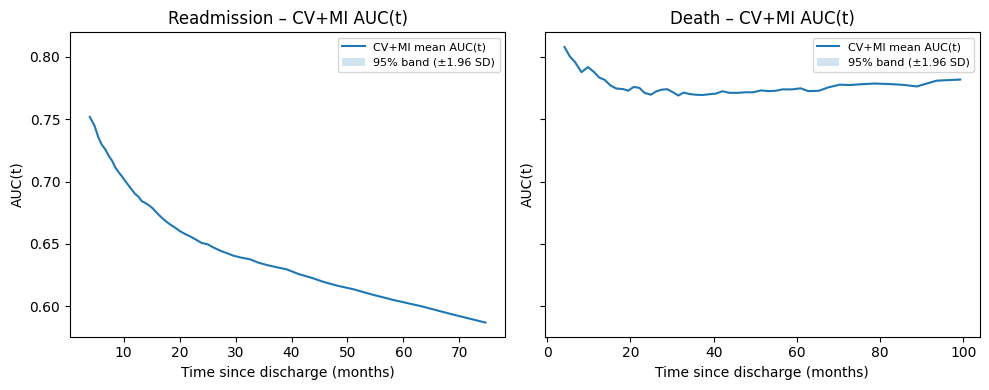

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

z = 1.96  # for ~95% band

# 95% bands from CV+MI
auc_readm_cv_lower = auc_readm_cv_mean - z * auc_readm_cv_sd
auc_readm_cv_upper = auc_readm_cv_mean + z * auc_readm_cv_sd

auc_death_cv_lower = auc_death_cv_mean - z * auc_death_cv_sd
auc_death_cv_upper = auc_death_cv_mean + z * auc_death_cv_sd

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# -------- READMISSION --------
ax = axes[0]
ax.plot(times_eval_readm, auc_readm_cv_mean, label="CV+MI mean AUC(t)")
ax.fill_between(
    times_eval_readm,
    auc_readm_cv_lower,
    auc_readm_cv_upper,
    alpha=0.2,
    label="95% band (±1.96 SD)"
)
ax.set_xlabel("Time since discharge (months)")
ax.set_ylabel("AUC(t)")
ax.set_title("Readmission – CV+MI AUC(t)")
ax.legend(fontsize=8, loc="upper right")

# -------- DEATH --------
ax2 = axes[1]
ax2.plot(times_eval_death, auc_death_cv_mean, label="CV+MI mean AUC(t)")
ax2.fill_between(
    times_eval_death,
    auc_death_cv_lower,
    auc_death_cv_upper,
    alpha=0.2,
    label="95% band (±1.96 SD)"
)
ax2.set_xlabel("Time since discharge (months)")
ax2.set_ylabel("AUC(t)")
ax2.set_title("Death – CV+MI AUC(t)")
ax2.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("cv_mi_auc_curves.png", dpi=600, bbox_inches="tight")
plt.show()



For readmission, we observe that AUC(*t*) starts around ~0.68 and drops down to 0.65 after discharge. Then, drops down to ~0.60. We can say that the model show modest discrimination.

For death, discrimination is high early (~0.82-0.83), then drops to ~0.75 and stabilizes around 0.77 at 5 years since discharge.

In both models, performance is stable across imputations.

---



##### 2.4.2.2. Export database

In [ ]:
z = 1.96

# Build tidy tables for ggplot / reuse
df_auc_cv_readm = pd.DataFrame({
    "endpoint": "readmission",
    "time": times_eval_readm,
    "auc_mean": auc_readm_cv_mean,
    "auc_sd": auc_readm_cv_sd,
})
df_auc_cv_readm["auc_lower"] = df_auc_cv_readm["auc_mean"] - z * df_auc_cv_readm["auc_sd"]
df_auc_cv_readm["auc_upper"] = df_auc_cv_readm["auc_mean"] + z * df_auc_cv_readm["auc_sd"]

df_auc_cv_death = pd.DataFrame({
    "endpoint": "death",
    "time": times_eval_death,
    "auc_mean": auc_death_cv_mean,
    "auc_sd": auc_death_cv_sd,
})
df_auc_cv_death["auc_lower"] = df_auc_cv_death["auc_mean"] - z * df_auc_cv_death["auc_sd"]
df_auc_cv_death["auc_upper"] = df_auc_cv_death["auc_mean"] + z * df_auc_cv_death["auc_sd"]

df_auc_cv_all = pd.concat([df_auc_cv_readm, df_auc_cv_death], ignore_index=True)

df_auc_cv_all.to_parquet("cv_mi_auc_curves.parquet", index=False)
print("Saved: cv_mi_auc_curves.parquet")


Saved: cv_mi_auc_curves.parquet


#### 2.4.3. Export key objects

Assuming that only the predictors are the elements that change in the database, we only exported one structure of survival for each outcome

In [ ]:
import pandas as pd
import numpy as np

# ---- 2) Outcomes: readmission ----
df_y_readm = pd.DataFrame({
    "event": y_surv_readm["event"].astype(bool),
    "time":  y_surv_readm["time"].astype(float),
})
df_y_readm.to_parquet("y_surv_readm.parquet", index=False)
print("Saved y_surv_readm.parquet")

# ---- 3) Outcomes: death ----
df_y_death = pd.DataFrame({
    "event": y_surv_death["event"].astype(bool),
    "time":  y_surv_death["time"].astype(float),
})
df_y_death.to_parquet("y_surv_death.parquet", index=False)
print("Saved y_surv_death.parquet")

# ---- 4) Time grids for Brier/IBS ----
pd.DataFrame({"time": times_eval_readm}).to_parquet(
    "times_eval_readm.parquet", index=False
)
pd.DataFrame({"time": times_eval_death}).to_parquet(
    "times_eval_death.parquet", index=False
)
print("Saved times_eval_readm.parquet and times_eval_death.parquet")


Saved y_surv_readm.parquet
Saved y_surv_death.parquet
Saved times_eval_readm.parquet and times_eval_death.parquet


In [ ]:
import pandas as pd

# y_surv_readm: structured array with fields "event" and "time"
df_y_readm = pd.DataFrame({
    "event": y_surv_readm["event"].astype(bool),
    "time":  y_surv_readm["time"].astype(float),
})
df_y_readm.to_parquet("y_surv_readm.parquet", index=False)
print("Saved y_surv_readm.parquet")

# y_surv_death: same idea
df_y_death = pd.DataFrame({
    "event": y_surv_death["event"].astype(bool),
    "time":  y_surv_death["time"].astype(float),
})
df_y_death.to_parquet("y_surv_death.parquet", index=False)
print("Saved y_surv_death.parquet")

# Create lists
y_surv_readm_list = [y_surv_readm_1, y_surv_readm_2, y_surv_readm_3, y_surv_readm_4, y_surv_readm_5]
y_surv_death_list = [y_surv_death_1, y_surv_death_2, y_surv_death_3, y_surv_death_4, y_surv_death_5]

import numpy as np

# Save readmission data
np.savez_compressed(
    "y_surv_readm_list.npz",
    imputation_1=y_surv_readm_list[0],
    imputation_2=y_surv_readm_list[1],
    imputation_3=y_surv_readm_list[2],
    imputation_4=y_surv_readm_list[3],
    imputation_5=y_surv_readm_list[4]
)

# Save death data
np.savez_compressed(
    "y_surv_death_list.npz",
    imputation_1=y_surv_death_list[0],
    imputation_2=y_surv_death_list[1],
    imputation_3=y_surv_death_list[2],
    imputation_4=y_surv_death_list[3],
    imputation_5=y_surv_death_list[4]
)

print("✓ Saved to NumPy format (compressed)")

Saved y_surv_readm.parquet
Saved y_surv_death.parquet
✓ Saved to NumPy format (compressed)


#### 2.4.4. Compare to KM (null)


##### 2.4.4.a.Error IBS


In [ ]:
from sksurv.metrics import integrated_brier_score
from sksurv.linear_model import CoxPHSurvivalAnalysis # Or just use KM directly
from sksurv.nonparametric import kaplan_meier_estimator
import numpy as np

# 1. Calculate the Kaplan-Meier Estimate (The "Null" Prediction)
# We need to create a probability matrix where every row is the KM curve
km_times, km_probs = kaplan_meier_estimator(y_surv_readm["event"], y_surv_readm["time"])

# Interpolate KM probabilities to match your 'times_eval'
# This creates a "Null Prediction" where every patient gets the exact same probability
null_probs = np.interp(times_eval_readm, km_times, km_probs)
null_preds = np.tile(null_probs, (len(y_surv_readm), 1))

# 2. Calculate IBS for the Null Model
null_ibs = integrated_brier_score(y_surv_readm, y_surv_readm, null_preds, times_eval_readm)

print(f"Model IBS: 0.1427")
print(f"Null (KM) IBS: {null_ibs:.4f}")

if 0.1427 < null_ibs - 0.005:
    print("VERDICT: The model has predictive power.")
else:
    print("VERDICT: The model is NOT performing better than random guessing (Kaplan-Meier).")

Model IBS: 0.1427
Null (KM) IBS: 0.1351
VERDICT: The model is NOT performing better than random guessing (Kaplan-Meier).


In [ ]:
from sksurv.metrics import integrated_brier_score
from sksurv.nonparametric import kaplan_meier_estimator
import numpy as np

# 1. Calculate the Kaplan-Meier Estimate (The "Average" Prediction)
km_times, km_probs = kaplan_meier_estimator(y_surv_death["event"], y_surv_death["time"])

# 2. Interpolate KM probabilities to match your evaluation times
# Note: Ensure 'times_eval_death' is defined in your environment
null_probs = np.interp(times_eval_death, km_times, km_probs)

# 3. Create the "Null Prediction" matrix (Same prediction for everyone)
null_preds = np.tile(null_probs, (len(y_surv_death), 1))

# 4. Calculate IBS for the Null Model
null_ibs_death = integrated_brier_score(y_surv_death, y_surv_death, null_preds, times_eval_death)

print(f"Model IBS:  0.0351") # From your logs
print(f"Null IBS:   {null_ibs_death:.4f}")

diff = 0.0351 - null_ibs_death

if abs(diff) < 0.001:
    print("\nCONCLUSION: The model is effectively ignoring all predictors.")
    print("It provides no value over a simple population average.")
else:
    print(f"\nCONCLUSION: There is a tiny difference ({diff:.5f}), but likely not clinically relevant.")

Model IBS:  0.0351
Null IBS:   0.0335

CONCLUSION: There is a tiny difference (0.00162), but likely not clinically relevant.


##### 2.4.4.b.Discrimination

In [ ]:
import numpy as np
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.metrics import concordance_index_ipcw
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxnetSurvivalAnalysis

# --- Settings (reuse your existing ones) ---
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=2125)

# Choose alpha index as before (ensure coxnet_readm_list/coxnet_death_list exist if you want to reuse)
alpha_idx_readm = len(coxnet_readm_list[0].alphas_) // 2
alpha_idx_death = len(coxnet_death_list[0].alphas_) // 2

# Containers across imputations
# Each element will be an array of shape (n_times,)
model_c_readm_by_imp = []
null_c_readm_by_imp  = []

model_c_death_by_imp = []
null_c_death_by_imp  = []

# Helper: compute null constant risk at a given time grid from training KM
def km_null_risk_vector(events_train, times_train, times_eval):
    # km_times: sorted times where KM changes; km_probs: survival probabilities
    km_times, km_probs = kaplan_meier_estimator(events_train, times_train)
    # survival at each eval time (interpolate)
    surv_at_eval = np.interp(times_eval, km_times, km_probs)
    # risk = 1 - survival
    return 1.0 - surv_at_eval  # shape (n_times,)

# Loop imputations
for d, X_imp in enumerate(X_encoded_list_final):
    print(f"\n=== Imputation {d} ===")
    n_samples = X_imp.shape[0]

    # Per-fold arrays to collect Uno-C at each time (lists of arrays)
    model_c_readm_folds = []
    null_c_readm_folds  = []

    model_c_death_folds = []
    null_c_death_folds  = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(np.arange(n_samples))):
        print(f"  Fold {fold+1}/{n_splits}")

        # Split X
        X_train = X_imp.iloc[train_idx, :].copy()
        X_test  = X_imp.iloc[test_idx, :].copy()

        # y arrays (sksurv structured arrays)
        y_train_readm = y_surv_readm[train_idx]
        y_test_readm  = y_surv_readm[test_idx]

        y_train_death = y_surv_death[train_idx]
        y_test_death  = y_surv_death[test_idx]

        # ---- Fit model on training (same hyperparams as you used) ----
        # Readmission model
        model_readm = CoxnetSurvivalAnalysis(
            l1_ratio=0.9,
            alpha_min_ratio=0.01,
            n_alphas=50,
            normalize=True,
            fit_baseline_model=True,
            max_iter=100000,
            verbose=False
        )
        model_readm.fit(X_train, y_train_readm)
        alpha_readm = model_readm.alphas_[alpha_idx_readm]
        risk_readm_test = model_readm.predict(X_test, alpha=alpha_readm)

        # Death model
        model_death = CoxnetSurvivalAnalysis(
            l1_ratio=0.9,
            alpha_min_ratio=0.01,
            n_alphas=50,
            normalize=True,
            fit_baseline_model=True,
            max_iter=100000,
            verbose=False
        )
        model_death.fit(X_train, y_train_death)
        alpha_death = model_death.alphas_[alpha_idx_death]
        risk_death_test = model_death.predict(X_test, alpha=alpha_death)

        # ---- Null (KM) constant risk vectors evaluated at each time in the grid ----
        # For readmission: compute scalar risk at each eval time from training KM, then repeat per test subject
        km_risk_readm_eval = km_null_risk_vector(y_train_readm["event"], y_train_readm["time"], times_eval_readm)
        # For concordance_index_ipcw we need a 1D risk vector per test subject; but we want Uno-C at each time.
        # We'll compute Uno-C separately for each time t by passing tau=t and a constant risk vector.
        # Same for death:
        km_risk_death_eval = km_null_risk_vector(y_train_death["event"], y_train_death["time"], times_eval_death)

        # ---- Compute Uno-C at each time for model and null ----
        # Readmission: loop times_eval_readm
        model_c_readm_t = []
        null_c_readm_t  = []
        for t_idx, t in enumerate(times_eval_readm):
            # model risk: use risk_readm_test (1D) and compute concordance at tau=t
            c_model = concordance_index_ipcw(y_train_readm, y_test_readm, risk_readm_test, tau=float(t))[0]
            model_c_readm_t.append(c_model)
            # null risk: constant value for all test subjects at this t
            risk_null_val = float(km_risk_readm_eval[t_idx])
            risk_null_vec = np.repeat(risk_null_val, len(test_idx))
            c_null = concordance_index_ipcw(y_train_readm, y_test_readm, risk_null_vec, tau=float(t))[0]
            null_c_readm_t.append(c_null)

        model_c_readm_folds.append(np.array(model_c_readm_t))
        null_c_readm_folds.append(np.array(null_c_readm_t))

        # Death: loop times_eval_death
        model_c_death_t = []
        null_c_death_t  = []
        for t_idx, t in enumerate(times_eval_death):
            c_model = concordance_index_ipcw(y_train_death, y_test_death, risk_death_test, tau=float(t))[0]
            model_c_death_t.append(c_model)
            risk_null_val = float(km_risk_death_eval[t_idx])
            risk_null_vec = np.repeat(risk_null_val, len(test_idx))
            c_null = concordance_index_ipcw(y_train_death, y_test_death, risk_null_vec, tau=float(t))[0]
            null_c_death_t.append(c_null)

        model_c_death_folds.append(np.array(model_c_death_t))
        null_c_death_folds.append(np.array(null_c_death_t))

        # Optional per-fold print (show first and last timepoints)
        print(f"    Readm model C (first,last): {model_c_readm_t[0]:.3f}, {model_c_readm_t[-1]:.3f}")
        print(f"    Readm null  C (first,last): {null_c_readm_t[0]:.3f}, {null_c_readm_t[-1]:.3f}")
        print(f"    Death  model C (first,last): {model_c_death_t[0]:.3f}, {model_c_death_t[-1]:.3f}")
        print(f"    Death  null  C (first,last): {null_c_death_t[0]:.3f}, {null_c_death_t[-1]:.3f}")

    # --- Average across folds within this imputation (elementwise mean across fold arrays) ---
    mean_model_c_readm = np.mean(np.stack(model_c_readm_folds, axis=0), axis=0)  # shape (len(times_eval_readm),)
    mean_null_c_readm  = np.mean(np.stack(null_c_readm_folds, axis=0), axis=0)

    mean_model_c_death = np.mean(np.stack(model_c_death_folds, axis=0), axis=0)  # shape (len(times_eval_death),)
    mean_null_c_death  = np.mean(np.stack(null_c_death_folds, axis=0), axis=0)

    model_c_readm_by_imp.append(mean_model_c_readm)
    null_c_readm_by_imp.append(mean_null_c_readm)

    model_c_death_by_imp.append(mean_model_c_death)
    null_c_death_by_imp.append(mean_null_c_death)

    print(f"  => Imputation {d} mean model C_readm (avg over folds): {np.mean(mean_model_c_readm):.4f}")
    print(f"  => Imputation {d} mean null  C_readm (avg over folds): {np.mean(mean_null_c_readm):.4f}")
    print(f"  => Imputation {d} mean model C_death (avg over folds): {np.mean(mean_model_c_death):.4f}")
    print(f"  => Imputation {d} mean null  C_death (avg over folds): {np.mean(mean_null_c_death):.4f}")

# ---------- Pool across imputations ----------
model_c_readm_stack = np.stack(model_c_readm_by_imp, axis=0)  # shape (m_imps, n_times_readm)
null_c_readm_stack  = np.stack(null_c_readm_by_imp, axis=0)

model_c_death_stack = np.stack(model_c_death_by_imp, axis=0)  # shape (m_imps, n_times_death)
null_c_death_stack  = np.stack(null_c_death_by_imp, axis=0)

# Pooled mean and SD across imputations (timewise)
model_c_readm_mean = model_c_readm_stack.mean(axis=0)
model_c_readm_sd   = model_c_readm_stack.std(axis=0, ddof=1)

null_c_readm_mean  = null_c_readm_stack.mean(axis=0)
null_c_readm_sd    = null_c_readm_stack.std(axis=0, ddof=1)

model_c_death_mean = model_c_death_stack.mean(axis=0)
model_c_death_sd   = model_c_death_stack.std(axis=0, ddof=1)

null_c_death_mean  = null_c_death_stack.mean(axis=0)
null_c_death_sd    = null_c_death_stack.std(axis=0, ddof=1)

# Timewise difference (model - null)
diff_readm_time = model_c_readm_mean - null_c_readm_mean
diff_death_time = model_c_death_mean - null_c_death_mean



=== Imputation 0 ===
  Fold 1/5
    Readm model C (first,last): 0.743, 0.611
    Readm null  C (first,last): 0.500, 0.500
    Death  model C (first,last): 0.858, 0.751
    Death  null  C (first,last): 0.500, 0.500
  Fold 2/5
    Readm model C (first,last): 0.764, 0.623
    Readm null  C (first,last): 0.500, 0.500
    Death  model C (first,last): 0.813, 0.731
    Death  null  C (first,last): 0.500, 0.500
  Fold 3/5
    Readm model C (first,last): 0.784, 0.621
    Readm null  C (first,last): 0.500, 0.500
    Death  model C (first,last): 0.851, 0.733
    Death  null  C (first,last): 0.500, 0.500
  Fold 4/5
    Readm model C (first,last): 0.754, 0.610
    Readm null  C (first,last): 0.500, 0.500
    Death  model C (first,last): 0.725, 0.741
    Death  null  C (first,last): 0.500, 0.500
  Fold 5/5
    Readm model C (first,last): 0.714, 0.606
    Readm null  C (first,last): 0.500, 0.500
    Death  model C (first,last): 0.791, 0.747
    Death  null  C (first,last): 0.500, 0.500
  => Imputati

In [ ]:
mean_diff_readm = diff_readm_time.mean()
mean_diff_death = diff_death_time.mean()
print("\n=== Summary (pooled across imputations) ===")
print(f"Readmission: mean(model C across times) = {model_c_readm_mean.mean():.4f} ± {model_c_readm_sd.mean():.4f}")
print(f" mean(null C across times) = {null_c_readm_mean.mean():.4f} ± {null_c_readm_sd.mean():.4f}")
print(f" mean difference (model - null) across times = {mean_diff_readm:.4f}")
print(f"Death : mean(model C across times) = {model_c_death_mean.mean():.4f} ± {model_c_death_sd.mean():.4f}")
print(f" mean(null C across times) = {null_c_death_mean.mean():.4f} ± {null_c_death_sd.mean():.4f}")
print(f" mean difference (model - null) across times = {mean_diff_death:.4f}")
# Optional: return or store results for plotting
results = {"times_eval_readm": times_eval_readm,
           "model_c_readm_mean": model_c_readm_mean,
            "model_c_readm_sd": model_c_readm_sd,
            "null_c_readm_mean": null_c_readm_mean,
            "null_c_readm_sd": null_c_readm_sd,
            "diff_readm_time": diff_readm_time,
            "times_eval_death": times_eval_death,
            "model_c_death_mean": model_c_death_mean,
            "model_c_death_sd": model_c_death_sd,
            "null_c_death_mean": null_c_death_mean,
            "null_c_death_sd": null_c_death_sd,
            "diff_death_time": diff_death_time
}


=== Summary (pooled across imputations) ===
Readmission: mean(model C across times) = 0.6646 ± 0.0001
 mean(null C across times) = 0.5000 ± 0.0000
 mean difference (model - null) across times = 0.1646
Death : mean(model C across times) = 0.7671 ± 0.0002
 mean(null C across times) = 0.5000 ± 0.0000
 mean difference (model - null) across times = 0.2671


# Save progress

In [ ]:

# Save each DataFrame in a list to parquet files (loop)
for i, df in enumerate(X_encoded_list_final):
    df.to_parquet(f"imputation_{i}.parquet", index=False)

# Or save a list as a single pickle/parquet archive
import pandas as pd
pd.to_pickle(X_encoded_list_final, "imputations_list.pkl")
# load: X_encoded_list_final = pd.read_pickle("imputations_list.pkl")

#times_eval_readm.parquet and times_eval_death.parquet




1.   Elemento de la lista
2.   Elemento de la lista



---



# Use center ID

I used leave-one-out evaluation, showing how well the model generalizes to each specific center.

In [ ]:
def evaluate_by_individual_center(
    X_list,
    y_surv,
    times_eval,
    groups,
    l1_ratio=0.9,
    alpha_min_ratio=0.01,
    n_alphas=50,
    alpha_idx=25,
    max_iter=100000,
):
    """
    Evaluate each center individually using leave-one-center-out.
    Train on all other centers, test on target center.
    """
    if hasattr(X_list[0], 'values'):
        feature_names = X_list[0].columns.tolist()
        X_arrays = [X.values.astype(np.float64) for X in X_list]
    else:
        X_arrays = X_list

    times_eval = np.asarray(times_eval, dtype=np.float64)
    groups = np.asarray(groups)
    unique_centers = np.unique(groups)

    # Remove 'missing_center' if present
    unique_centers = [c for c in unique_centers if c != 'missing_center']

    results_by_center = []

    for center in unique_centers:
        print(f"Evaluating center: {center}")

        center_cindex = []
        center_ibs = []

        # Get indices for this center
        test_idx = np.where(groups == center)[0]
        train_idx = np.where(groups != center)[0]

        # Skip if too few samples
        if len(test_idx) < 10:
            print(f"  Skipping (only {len(test_idx)} samples)")
            continue

        # Evaluate on each imputation
        for d, X_arr in enumerate(X_arrays):
            X_train = X_arr[train_idx]
            X_test = X_arr[test_idx]
            y_train = y_surv[train_idx]
            y_test = y_surv[test_idx]

            # Check if enough events in both sets
            n_events_train = y_train['event'].sum()
            n_events_test = y_test['event'].sum()

            if n_events_train < 10 or n_events_test < 2:
                print(f"  Imp {d}: Skipping (events: train={n_events_train}, test={n_events_test})")
                continue

            try:
                # Fit model
                model = CoxnetSurvivalAnalysis(
                    l1_ratio=l1_ratio,
                    alpha_min_ratio=alpha_min_ratio,
                    n_alphas=n_alphas,
                    normalize=True,
                    fit_baseline_model=True,
                    max_iter=max_iter,
                    verbose=False,
                )
                model.fit(X_train, y_train)

                eff_alpha_idx = min(alpha_idx, len(model.alphas_) - 1)
                alpha_val = model.alphas_[eff_alpha_idx]

                # C-index
                risk_scores = model.predict(X_test, alpha=alpha_val)
                cindex, _, _, _, _ = concordance_index_ipcw(
                    survival_train=y_train,
                    survival_test=y_test,
                    estimate=risk_scores,
                    tau=times_eval[-1]
                )
                center_cindex.append(cindex)

                # IBS
                baseline_estimator = model._baseline_models[eff_alpha_idx]
                S0 = baseline_estimator.baseline_survival_(times_eval)
                S_test = np.power(S0[None, :], np.exp(risk_scores[:, None]))

                times_brier, _ = brier_score(
                    survival_train=y_train,
                    survival_test=y_test,
                    estimate=S_test,
                    times=times_eval,
                )
                S_test_valid = S_test[:, :len(times_brier)]

                ibs = integrated_brier_score(
                    survival_train=y_train,
                    survival_test=y_test,
                    estimate=S_test_valid,
                    times=times_brier,
                )
                center_ibs.append(ibs)

            except Exception as e:
                print(f"  Imp {d}: Error - {e}")
                continue

        # Aggregate across imputations for this center
        if len(center_cindex) > 0:
            results_by_center.append({
                'center': center,
                'cindex_mean': np.mean(center_cindex),
                'cindex_sd': np.std(center_cindex, ddof=1) if len(center_cindex) > 1 else 0,
                'ibs_mean': np.mean(center_ibs),
                'ibs_sd': np.std(center_ibs, ddof=1) if len(center_ibs) > 1 else 0,
                'n_samples': len(test_idx),
                'n_events': y_surv[test_idx]['event'].sum(),
                'n_imputations': len(center_cindex)
            })
            print(f"  C-index: {results_by_center[-1]['cindex_mean']:.3f}, IBS: {results_by_center[-1]['ibs_mean']:.4f}")

    df_center = pd.DataFrame(results_by_center).sort_values('cindex_mean', ascending=False)
    return df_center

# Run individual center evaluation
df_centers_individual = evaluate_by_individual_center(
    X_list=X_reduced_list,
    y_surv=y_surv_readm,
    times_eval=times_eval_readm,
    groups=groups,
)

print(f"\n=== Individual Center Performance ===")
print(f"Total centers evaluated: {len(df_centers_individual)}")
print(f"\nC-index across centers: {df_centers_individual['cindex_mean'].mean():.3f} ± {df_centers_individual['cindex_mean'].std():.3f}")
print(f"IBS across centers: {df_centers_individual['ibs_mean'].mean():.4f} ± {df_centers_individual['ibs_mean'].std():.4f}")

print("\nTop 10 centers:")
print(df_centers_individual.head(10))

print("\nBottom 10 centers:")
print(df_centers_individual.tail(10))

#2hrs.

#Total centers evaluated: 389
#C-index across centers: 0.591 ± 0.080
#IBS across centers: 0.1476 ± 0.0522


Do it for time to death

In [ ]:
df_centers_individual_death = evaluate_by_individual_center(
    X_list=X_reduced_list,
    y_surv=y_surv_death,
    times_eval=times_eval_death,
    groups=groups,
)
print(f"\n=== Individual Center Performance ===")
print(f"Total centers evaluated: {len(df_centers_individual_death)}")
print(f"\nC-index across centers: {df_centers_individual_death['cindex_mean'].mean():.3f} ± {df_centers_individual['cindex_mean'].std():.3f}")
print(f"IBS across centers: {df_centers_individual_death['ibs_mean'].mean():.4f} ± {df_centers_individual['ibs_mean'].std():.4f}")

print("\nTop 10 centers:")
print(df_centers_individual_death.head(10))

print("\nBottom 10 centers:")
print(df_centers_individual_death.tail(10))


In [ ]:
df_centers_individual_readm = pd.DataFrame(df_centers_individual)
df_centers_individual_death = pd.DataFrame(df_centers_individual_death)

# --- The actual export step ---
file_path = 'df_centers_individual_readm.parquet'

df_centers_individual_readm.to_parquet(
    file_path,
    engine='pyarrow',  # Specify the engine (pyarrow is common and fast)
    index=False       # Set to True if you want to save the DataFrame index
)

print(f"DataFrame successfully exported to {file_path}")

# --- The actual export step ---
file_path = 'df_centers_individual_death.parquet'

df_centers_individual_death.to_parquet(
    file_path,
    engine='pyarrow',  # Specify the engine (pyarrow is common and fast)
    index=False       # Set to True if you want to save the DataFrame index
)

print(f"DataFrame successfully exported to {file_path}")

## 4.Net benefit

In [ ]:
import numpy as np
import pandas as pd

# Choose a time horizon in months, e.g. 24 months (you can change this)
t0 = 24.0

time_readm = df_final["readmit_time_from_disch_m"].to_numpy()
event_readm = (df_final["readmit_event"].to_numpy() == 1)

# Keep only subjects with follow-up >= t0
mask = time_readm >= t0

time_t0 = time_readm[mask]
event_t0 = event_readm[mask]  # will be True if event occurred at any time (but we restrict by time)

# Define binary endpoint: event by t0
y_bin_t0 = ((time_t0 <= t0) & (event_t0)).astype(int)

print("N used for DCA (readmission):", y_bin_t0.shape[0],
      "Prevalence by t0:", y_bin_t0.mean())


NameError: name 'df_final' is not defined

In [ ]:
# Subset X_reduced to the same mask
X_dca = X_reduced.iloc[mask, :]

# Predict survival functions
sf_list_readm = coxnet_readm.predict_survival_function(
    X_dca, alpha=alpha_readm, return_array=False
)

# Survival at t0, then risk = 1 - S(t0)
S_t0 = np.array([fn(t0) for fn in sf_list_readm])
risk_t0 = 1.0 - S_t0

print("Risk range at t0:", risk_t0.min(), risk_t0.max())


In [ ]:
def decision_curve_binary(y_true, risk, thresholds):
    """
    y_true: binary (0/1), shape (N,)
    risk: predicted risk in [0,1], shape (N,)
    thresholds: array of risk thresholds (e.g. np.linspace(0.05, 0.5, 10))

    Returns:
      nb_model: net benefit of the model for each threshold
      nb_all: net benefit of treat-all strategy
      nb_none: zeros (treat-none)
    """
    y_true = np.asarray(y_true).astype(int)
    risk = np.asarray(risk).astype(float)
    N = len(y_true)
    prev = y_true.mean()

    nb_model = []
    nb_all = []
    nb_none = np.zeros_like(thresholds, dtype=float)

    for pt in thresholds:
        treated = risk >= pt
        tp = np.sum((treated) & (y_true == 1))
        fp = np.sum((treated) & (y_true == 0))

        nb = (tp / N) - (fp / N) * (pt / (1.0 - pt))
        nb_model.append(nb)

        # Treat-all: everyone is treated
        tp_all = np.sum(y_true == 1)
        fp_all = np.sum(y_true == 0)
        nb_all_pt = (tp_all / N) - (fp_all / N) * (pt / (1.0 - pt))
        nb_all.append(nb_all_pt)

    return np.array(nb_model), np.array(nb_all), nb_none


In [ ]:
# Choose thresholds, e.g. 0.05 to 0.5
thresholds = np.linspace(0.05, 0.50, 10)

nb_model_readm, nb_all_readm, nb_none_readm = decision_curve_binary(
    y_true = y_bin_t0,
    risk   = risk_t0,
    thresholds = thresholds
)


In [ ]:
df_dca_readm = pd.DataFrame({
    "outcome": "Readmission",
    "threshold": thresholds,
    "nb_model": nb_model_readm,
    "nb_all": nb_all_readm,
    "nb_none": nb_none_readm,
})

df_dca_readm.to_csv("dca_readmission_t0_24m.csv", index=False)


In [ ]:
# ---- Mortality DCA ----
t0_death = 60.0  # e.g. 5-year (60 months) horizon, or same t0 if you prefer

time_death = df_final["death_time_from_disch_m"].to_numpy()
event_death = (df_final["death_event"].to_numpy() == 1)

mask_death = time_death >= t0_death
time_t0_death = time_death[mask_death]
event_t0_death = event_death[mask_death]

y_bin_death_t0 = ((time_t0_death <= t0_death) & (event_t0_death)).astype(int)

X_dca_death = X_reduced.iloc[mask_death, :]

sf_list_death = coxnet_death.predict_survival_function(
    X_dca_death, alpha=alpha_death, return_array=False
)
S_t0_death = np.array([fn(t0_death) for fn in sf_list_death])
risk_t0_death = 1.0 - S_t0_death

thresholds_death = np.linspace(0.01, 0.30, 10)  # mortality risk usually lower
nb_model_death, nb_all_death, nb_none_death = decision_curve_binary(
    y_true = y_bin_death_t0,
    risk   = risk_t0_death,
    thresholds = thresholds_death
)

df_dca_death = pd.DataFrame({
    "outcome": "Death",
    "threshold": thresholds_death,
    "nb_model": nb_model_death,
    "nb_all": nb_all_death,
    "nb_none": nb_none_death,
})

df_dca_death.to_csv("dca_death_t0_60m.csv", index=False)
